<a href="https://colab.research.google.com/github/dudavsr/analise_de_complexidade_edb2/blob/main/EDB2_THIS_IS_THE_ENDDDD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Instalação do g++ pra poder utilizar c++ no collab
!apt-get update
!apt-get install g++ -y

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Fetched 261 kB in 1s (181 kB/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
g++ is already the newest version 

In [ ]:
#Declarando os algoritmos Insertion, Merge e Quick
%%writefile algoritmos.hpp
#ifndef ALGORITMOS_HPP
#define ALGORITMOS_HPP

#include <vector>
using namespace std;

void insertionSort(vector<int>& v);

void merge(vector<int>& v, int inicio, int meio, int fim);
void mergeSort(vector<int>& v, int inicio, int fim);

int particionar(vector<int>& v, int inicio, int fim);
void quickSort(vector<int>& v, int inicio, int fim);

#endif

Overwriting algoritmos.hpp


In [ ]:
#Implementação dos algoritmos mencionados anteriormente, primeiro o Insertion, depois o Merge e por fim o Quick Sort.
%%writefile algoritmos.cpp
#include "algoritmos.hpp"
#include <vector>
#include <utility>

using namespace std;

void insertionSort(vector<int>& v) {
    for (int i = 1; i < (int)v.size(); i++) {
        int chave = v[i];
        int j = i - 1;

        while (j >= 0 && v[j] > chave) {
            v[j + 1] = v[j];
            j--;
        }
        v[j + 1] = chave;
    }
}

void merge(vector<int>& v, int inicio, int meio, int fim) {
    int n1 = meio - inicio + 1;
    int n2 = fim - meio;

    vector<int> esquerda(n1), direita(n2);

    for (int i = 0; i < n1; i++) {
        esquerda[i] = v[inicio + i];
    }

    for (int j = 0; j < n2; j++) {
        direita[j] = v[meio + 1 + j];
    }

    int i = 0, j = 0, k = inicio;

    while (i < n1 && j < n2) {
        if (esquerda[i] <= direita[j]) {
            v[k] = esquerda[i];
            i++;
        } else {
            v[k] = direita[j];
            j++;
        }
        k++;
    }

    while (i < n1) {
        v[k] = esquerda[i];
        i++;
        k++;
    }

    while (j < n2) {
        v[k] = direita[j];
        j++;
        k++;
    }
}

void mergeSort(vector<int>& v, int inicio, int fim) {
    if (inicio < fim) {
        int meio = inicio + (fim - inicio) / 2;
        mergeSort(v, inicio, meio);
        mergeSort(v, meio + 1, fim);
        merge(v, inicio, meio, fim);
    }
}


int particionar(vector<int>& v, int inicio, int fim) {
    int pivo = v[(inicio + fim) / 2];
    int i = inicio;
    int j = fim;

    while (i <= j) {
        while (v[i] < pivo) {
            i++;
        }

        while (v[j] > pivo) {
            j--;
        }

        if (i <= j) {
            swap(v[i], v[j]);
            i++;
            j--;
        }
    }

    return i;
}

void quickSort(vector<int>& v, int inicio, int fim) {
    if (inicio < fim) {
        int index = particionar(v, inicio, fim);

        if (inicio < index - 1) {
            quickSort(v, inicio, index - 1);
        }

        if (index < fim) {
            quickSort(v, index, fim);
        }
    }
}

Overwriting algoritmos.cpp


In [ ]:
#Declarando tanto a parte responsável pela medição de tempo como também a de geração de dados
%%writefile benchmark.hpp
#ifndef BENCHMARK_HPP
#define BENCHMARK_HPP

#include <vector>
using namespace std;

// Geração de entrada
vector<int> gerarVetor(int n);

// Medição de tempo
long long medirTempoInsertion(vector<int> v);
long long medirTempoMerge(vector<int> v);
long long medirTempoQuick(vector<int> v);

#endif

Overwriting benchmark.hpp


In [ ]:
#Implementação do que foi mencionado na célula anterior (medição de tempo e geração de dados)
%%writefile benchmark.cpp
#include "benchmark.hpp"
#include "algoritmos.hpp"
#include <vector>
#include <chrono>
#include <random>

using namespace std;
using namespace std::chrono;

vector<int> gerarVetor(int n) {
    vector<int> v(n);

    random_device rd;
    mt19937 gen(rd());
    uniform_int_distribution<> dist(0, 100000);

    for (int i = 0; i < n; i++) {
        v[i] = dist(gen);
    }

    return v;
}

long long medirTempoInsertion(vector<int> v) {
    auto inicio = high_resolution_clock::now();
    insertionSort(v);
    auto fim = high_resolution_clock::now();

    return duration_cast<microseconds>(fim - inicio).count();
}

long long medirTempoMerge(vector<int> v) {
    auto inicio = high_resolution_clock::now();
    if (!v.empty()) {
        mergeSort(v, 0, v.size() - 1);
    }
    auto fim = high_resolution_clock::now();

    return duration_cast<microseconds>(fim - inicio).count();
}

long long medirTempoQuick(vector<int> v) {
    auto inicio = high_resolution_clock::now();
    if (!v.empty()) {
        quickSort(v, 0, v.size() - 1);
    }
    auto fim = high_resolution_clock::now();

    return duration_cast<microseconds>(fim - inicio).count();
}

Overwriting benchmark.cpp


In [ ]:
#Main que executa os algoritmos anteriores para os diferentes tamanhos de entradas especificados abaixo e depois salva em CSV
%%writefile main.cpp
#include <iostream>
#include <vector>
#include <fstream>
#include "benchmark.hpp"

using namespace std;

int main() {
    vector<int> tamanhos = {100, 500, 1000, 5000, 10000, 20000};
    int repeticoes = 10;

    ofstream arquivo("resultados.csv");
    arquivo << "Algoritmo,n,tempo_medio\n";

    for (int n : tamanhos) {
        long long tempoInsertion = 0;
        long long tempoMerge = 0;
        long long tempoQuick = 0;

        for (int i = 0; i < repeticoes; i++) {
            vector<int> v = gerarVetor(n);

            tempoInsertion += medirTempoInsertion(v);
            tempoMerge += medirTempoMerge(v);
            tempoQuick += medirTempoQuick(v);
        }

        arquivo << "InsertionSort," << n << "," << tempoInsertion / repeticoes << "\n";
        arquivo << "MergeSort," << n << "," << tempoMerge / repeticoes << "\n";
        arquivo << "QuickSort," << n << "," << tempoQuick / repeticoes << "\n";
    }

    arquivo.close();

    cout << "CSV gerado com sucesso! Tá liberado para gerar a tabelinha" << endl;

    return 0;
}

Overwriting main.cpp


In [ ]:
#Compila pra executar de uma vez
!g++ main.cpp algoritmos.cpp benchmark.cpp -o programa

In [ ]:
#Executa
!./programa

CSV gerado com sucesso! Tá liberado para gerar a tabelinha


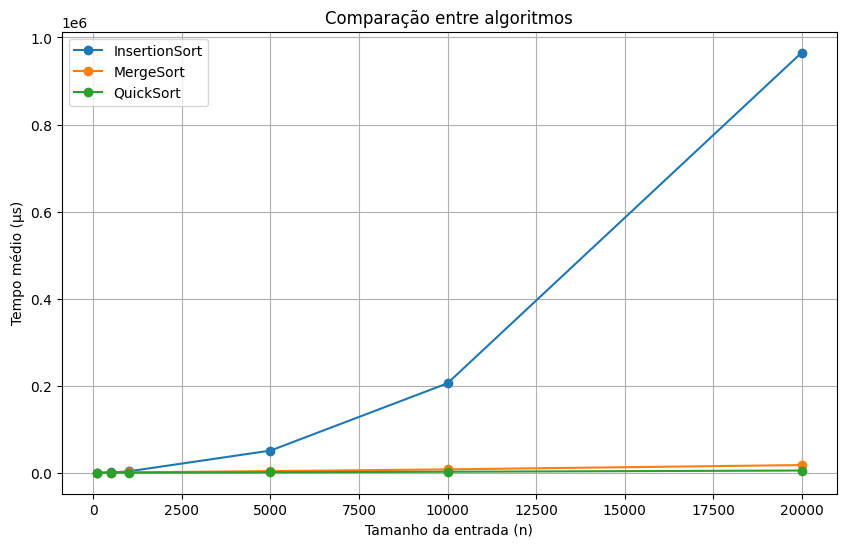

In [ ]:
#Importa (em python, antes tudo era c++) as bibliotecas para montar o gráfico dos 3 juntos e monta o gráfico.
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("resultados.csv")

plt.figure(figsize=(10,6))

for algoritmo in df["Algoritmo"].unique():
    dados = df[df["Algoritmo"] == algoritmo]
    plt.plot(dados["n"], dados["tempo_medio"], marker='o', label=algoritmo)

plt.xlabel("Tamanho da entrada (n)")
plt.ylabel("Tempo médio (μs)")
plt.title("Comparação entre algoritmos")
plt.legend()
plt.grid(True)

plt.show()

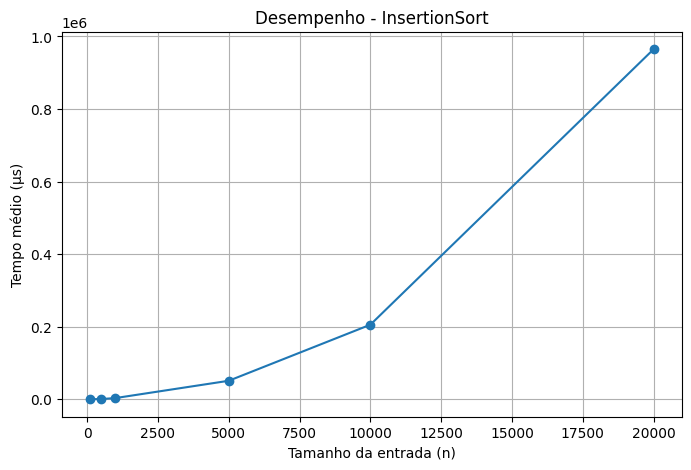

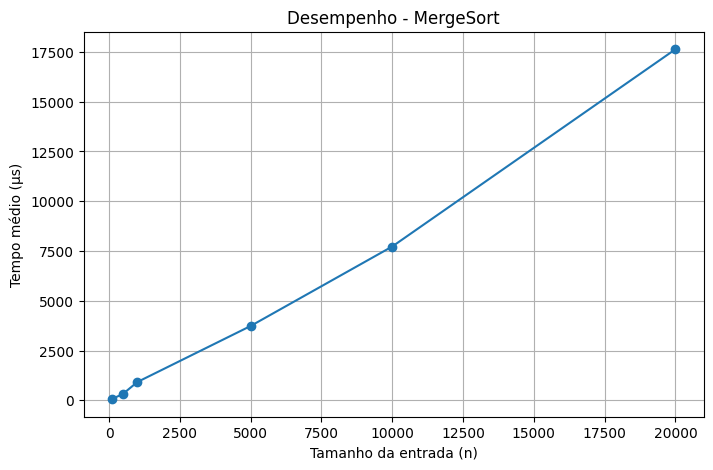

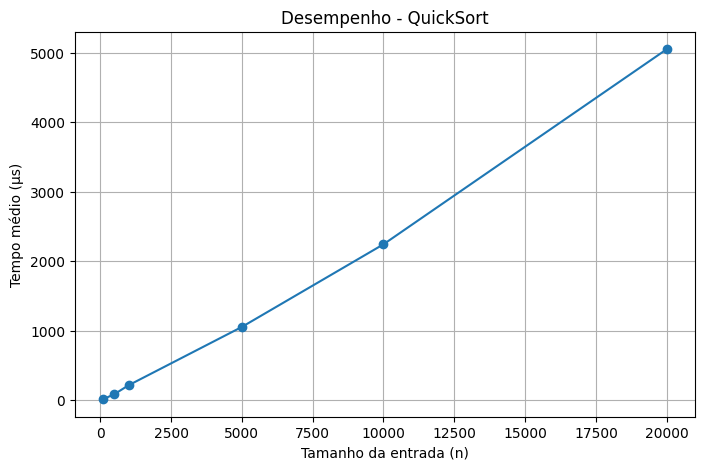

In [ ]:
#Importa (em python também) as bibliotecas para montar o gráfico de cada um dos sort individualmente.
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("resultados.csv")

for algoritmo in df["Algoritmo"].unique():
    dados = df[df["Algoritmo"] == algoritmo]

    plt.figure(figsize=(8,5))
    plt.plot(dados["n"], dados["tempo_medio"], marker='o')

    plt.xlabel("Tamanho da entrada (n)")
    plt.ylabel("Tempo médio (μs)")
    plt.title(f"Desempenho - {algoritmo}")
    plt.grid(True)

    plt.show()

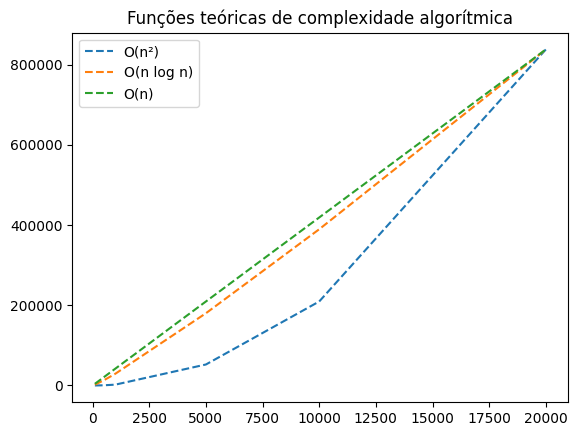

In [25]:
# Monta o gráfico das funções teóricas
import numpy as np

n = df["n"].values

O_n = n
O_nlogn = n * np.log2(n)
O_n2 = n**2

O_n = O_n / max(O_n) * max(df["tempo_medio"])
O_nlogn = O_nlogn / max(O_nlogn) * max(df["tempo_medio"])
O_n2 = O_n2 / max(O_n2) * max(df["tempo_medio"])

plt.title("Funções teóricas de complexidade algorítmica")
plt.plot(n, O_n2, '--', label="O(n²)")
plt.plot(n, O_nlogn, '--', label="O(n log n)")
plt.plot(n, O_n, '--', label="O(n)")
plt.legend()